# Q Learning RTOS Visualizations: 2 Fully CPU Intensive Tasks
### Braden Everson

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

In [2]:
logs = pd.read_csv("../data/rtos/2cpu/qlearn1.csv")
#logs = pd.read_csv("../data/rtos/2cpu/qlearn2.csv")
#logs = pd.read_csv("../data/rtos/2cpu/qlearn3.csv")
#logs = pd.read_csv("../data/rtos/2cpu/qlearn4.csv")
#logs = pd.read_csv("../data/rtos/2cpu/qlearn5.csv")

baseline = pd.read_csv("../data/rtos/2cpu/baseline1.csv")

In [3]:
logs.tail()

,task_id,timestamp,total_run_timf,total_io_wait_time,total_ready_wait_time,wait_pct,delta
995,C,5510213,5509194,0,5515158,0.500270,5
996,G,5515207,5510178,0,5524184,0.500635,5
997,C,5520213,5519194,0,5525168,0.500270,7
998,G,5525253,5520178,0,5534286,0.500638,5
999,C,5532293,5529286,0,5539258,0.500451,5


In [22]:
logs["delta"].max()

np.int64(15)

In [4]:
baseline.tail()

,task_id,timestamp,total_run_timf,total_io_wait_time,total_ready_wait_time,wait_pct,delta
995,C,9960043,9959046,0,9964980,0.500149,10
996,G,9970050,9960000,0,9984036,0.500603,10
997,C,9980043,9979046,0,9984990,0.500149,10
998,G,9990044,9980000,0,10004046,0.500602,10
999,C,10000043,9999046,0,10005000,0.500149,10


In [5]:
logs["wait_pct"].mean()

np.float64(0.50210655914)

In [6]:
baseline["wait_pct"].mean()

np.float64(0.50218253921)

## Kruskal Wallis

In [7]:
run0 = pd.read_csv("../data/rtos/2cpu/qlearn1.csv")
run1 = pd.read_csv("../data/rtos/2cpu/qlearn2.csv")
run2 = pd.read_csv("../data/rtos/2cpu/qlearn3.csv")
run3 = pd.read_csv("../data/rtos/2cpu/qlearn4.csv")
run4 = pd.read_csv("../data/rtos/2cpu/qlearn5.csv")

baseline0 = pd.read_csv("../data/rtos/2cpu/baseline1.csv")
baseline1 = pd.read_csv("../data/rtos/2cpu/baseline2.csv")
baseline2 = pd.read_csv("../data/rtos/2cpu/baseline3.csv")
baseline3 = pd.read_csv("../data/rtos/2cpu/baseline4.csv")
baseline4 = pd.read_csv("../data/rtos/2cpu/baseline5.csv")

In [8]:
avgs = [
        run0["wait_pct"].mean()*100,
        run1["wait_pct"].mean()*100,
        run2["wait_pct"].mean()*100,
        run3["wait_pct"].mean()*100,
        run4["wait_pct"].mean()*100
       ]

baseline = [
    baseline0["wait_pct"].mean()*100,
    baseline1["wait_pct"].mean()*100,
    baseline2["wait_pct"].mean()*100,
    baseline3["wait_pct"].mean()*100,
    baseline4["wait_pct"].mean()*100,
]

In [9]:
baseline

[np.float64(50.218253921),
 np.float64(50.218253921),
 np.float64(50.218253921),
 np.float64(50.218253921),
 np.float64(50.218253921)]

(50.21, 50.22)

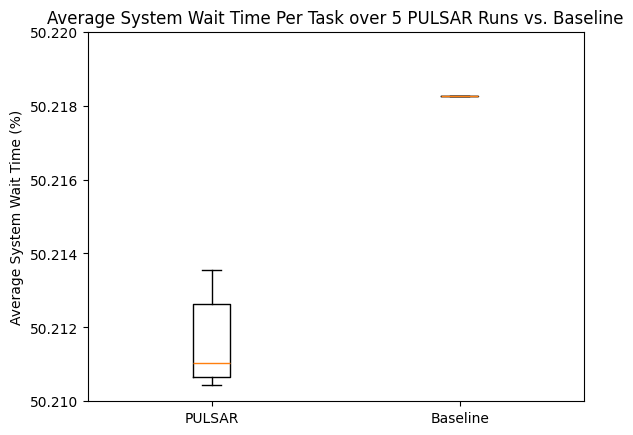

In [21]:
plt.boxplot([avgs, baseline], tick_labels=["PULSAR", "Baseline"])
plt.title("Average System Wait Time Per Task over 5 PULSAR Runs vs. Baseline")
plt.ylabel("Average System Wait Time (%)")
plt.ylim(50.21,50.220)

In [11]:
h_stat, p_val = stats.kruskal(avgs, baseline)

print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_val:.4f}")

H-statistic: 7.7586
P-value: 0.0053
